# Calibrating a market simulator jointly with its fundamental
### An ABM of central clearing — market-simulation walkthrough

Built on the Simudyne CCP risk-model scaffold, extended with a **data-derived fundamental** (real ES 1-min mid, overnight gaps kept), a **calibrated behavioural loop** (7 agent parameters), and a **client-clearing tier** (last section).

Focus: calibrating the **fundamental-value process jointly with the agent parameters**, via an XGBoost-surrogate simulated method of moments.

In [106]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

REPO = Path.cwd()
OUT = REPO / "output"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, SLATE, RED, AMBER, GREEN, INK = "#0284C7", "#64748B", "#DC2626", "#D97706", "#059669", "#0f172a"


## 1. The market simulator

One asset, a 1-minute call-auction limit order book (ES front-month), 100 agents in three classes. Prices emerge from the auction; the fundamental $V_t$ is the only exogenous input.

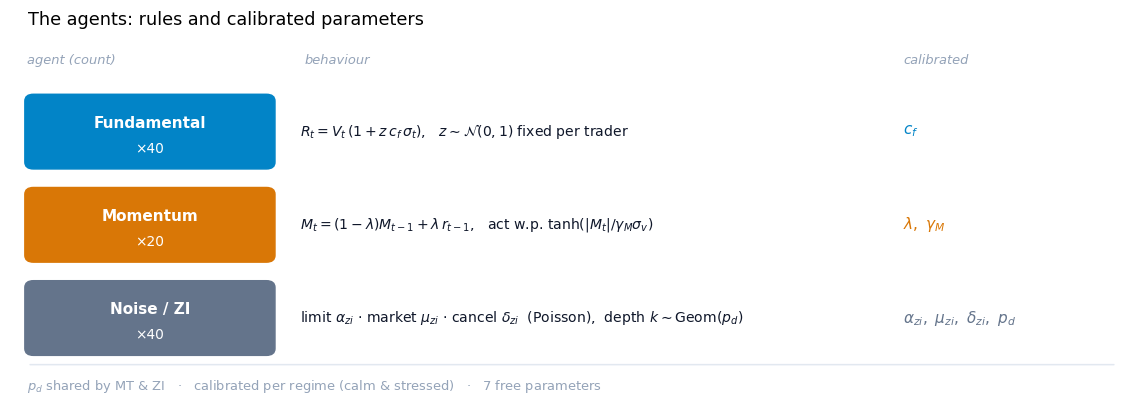

In [107]:
fig, ax = plt.subplots(figsize=(10.5, 3.9)); ax.set_xlim(0, 10.5); ax.set_ylim(0, 4.4); ax.axis("off"); ax.grid(False)
GREYT = "#94a3b8"
ax.text(0.15, 4.05, "agent (count)", color=GREYT, fontsize=8.5, style="italic")
ax.text(2.75, 4.05, "behaviour", color=GREYT, fontsize=8.5, style="italic")
ax.text(8.35, 4.05, "calibrated", color=GREYT, fontsize=8.5, style="italic")
rows = [
    (BLUE, "Fundamental", "×40", r"$R_t = V_t\,(1 + z\,c_f\,\sigma_t)$,   $z\sim\mathcal{N}(0,1)$ fixed per trader", r"$c_f$"),
    (AMBER, "Momentum", "×20", r"$M_t=(1-\lambda)M_{t-1}+\lambda\,r_{t-1}$,   act w.p. $\mathrm{tanh}(|M_t|/\gamma_M\sigma_v)$", r"$\lambda,\ \gamma_M$"),
    (SLATE, "Noise / ZI", "×40", r"limit $\alpha_{zi}$ · market $\mu_{zi}$ · cancel $\delta_{zi}$  (Poisson),  depth $k\sim\mathrm{Geom}(p_d)$", r"$\alpha_{zi},\ \mu_{zi},\ \delta_{zi},\ p_d$"),
]
for (col, name, cnt, rule, cal), y in zip(rows, [3.25, 2.15, 1.05]):
    ax.add_patch(FancyBboxPatch((0.15, y-0.42), 2.3, 0.84, boxstyle="round,pad=0.02,rounding_size=0.08", fc=col, ec=col, zorder=2))
    ax.text(1.30, y+0.10, name, color="white", fontsize=10, fontweight="bold", ha="center", va="center", zorder=3)
    ax.text(1.30, y-0.20, cnt, color="white", fontsize=9, ha="center", va="center", zorder=3)
    ax.text(2.70, y, rule, color=INK, fontsize=9.2, va="center")
    ax.text(8.35, y, cal, color=col, fontsize=10, va="center", fontweight="bold")
ax.annotate("", xy=(10.35, 0.5), xytext=(0.15, 0.5), arrowprops=dict(arrowstyle="-", color="#e2e8f0", lw=1))
ax.text(0.15, 0.20, r"$p_d$ shared by MT & ZI   ·   calibrated per regime (calm & stressed)   ·   7 free parameters", color=GREYT, fontsize=8.5)
ax.set_title("The agents: rules and calibrated parameters", fontsize=11.5, loc="left", x=0.015)
plt.tight_layout()

One cleared session runs in **≈ 0.3 s**. Built and run in-process below — three stressed sessions, the simulated mid tracking the real ES fundamental:

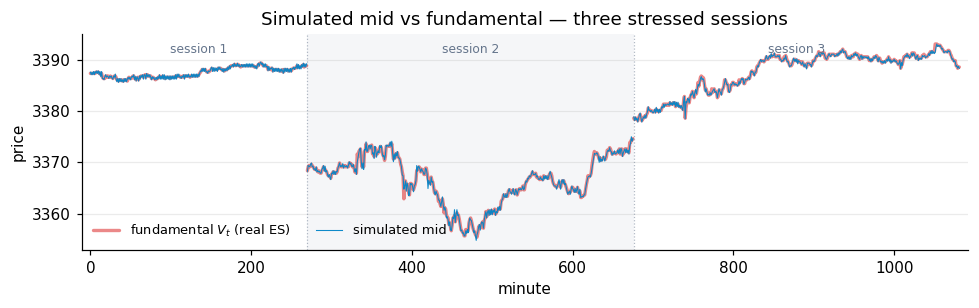

In [108]:
from model.globals import ModelParams, V0, CALIBRATED
from model.run_simulation import build_traders, build_clearing_tier
from model.agents import BankingClearingMember
from model.simulation import Simulation

params = ModelParams(n_fundamental=30, n_momentum=20, n_zi=40, n_bcm=10, n_nbcm=5,
                     n_bcm_with_clients=5, v0=V0["stressed"], tick_size=0.25,
                     dt_minutes=1.0, **CALIBRATED["stressed"], stressed=True)
traders = build_traders(params, seed=42)
ccp = build_clearing_tier(traders, params, seed=42)

# member / client bookkeeping (reused by the clearing map in section 5)
members = list(ccp.members.values())
clients = [t for t in traders if getattr(t, "clearing_member_id", None) is not None
           and not isinstance(t, BankingClearingMember)]
by_cm = {}
for c in clients:
    by_cm.setdefault(c.clearing_member_id, []).append(c)

sim = Simulation(params, traders, seed=42, ccp=ccp)
opens = sorted(i - sim._v_start for i in sim._day_start_rows if i - sim._v_start >= 0)
n_steps = opens[3] if len(opens) > 3 else 3 * 390          # exactly three full RTH sessions
sim.run(n_steps=n_steps)

mid = pd.Series(sim.history["mid_price"]).ffill().to_numpy()
fv = np.asarray(sim.history["fundamental"], float)
bnds = [b for b in opens if 0 < b < len(mid)]              # internal session opens
segs = np.split(np.arange(len(mid)), bnds)                 # break the line at each overnight gap
edges = [0] + bnds + [len(mid)]

fig, ax = plt.subplots(figsize=(9, 2.9)); ax.grid(True, axis="y", alpha=0.25); ax.grid(False, axis="x")
for k in range(len(edges) - 1):
    if k % 2 == 1:
        ax.axvspan(edges[k], edges[k + 1], color=SLATE, alpha=0.06, lw=0)
    ax.text((edges[k] + edges[k + 1]) / 2, 0.96, f"session {k + 1}", transform=ax.get_xaxis_transform(),
            ha="center", va="top", color=SLATE, fontsize=8)
for j, s in enumerate(segs):
    ax.plot(s, fv[s], color=RED, lw=2.2, alpha=0.55, solid_capstyle="round",
            label="fundamental $V_t$ (real ES)" if j == 0 else None)
    ax.plot(s, mid[s], color=BLUE, lw=0.7, alpha=0.95, label="simulated mid" if j == 0 else None)
for b in bnds:
    ax.axvline(b, color=SLATE, lw=0.8, ls=":", alpha=0.5)
ax.set(xlabel="minute", ylabel="price", title="Simulated mid vs fundamental — three stressed sessions")
ax.margins(x=0.01); ax.legend(frameon=False, loc="lower left", ncol=2, fontsize=8.5)
plt.tight_layout()

## 2. Calibration: matching return moments

Nothing in the clearing tier is calibrated, so the agents alone must reproduce the stylised facts of ES 1-minute returns. Five moment groups:

| symbol | pins down |
|:--|:--|
| $\mathrm{KS}$ | return distribution (whole CDF) |
| $V$ | volatility level |
| $\mathrm{ACF}_r$ | return autocorrelation |
| $\mathrm{ACF}_{\lvert r\rvert}$ | volatility clustering |
| $\mathrm{Hill}$ | tail heaviness |

The loss sums five standardised gaps:

$$
D(\theta)=\sum_{c}\Delta_c,\qquad
\Delta_c=\frac{1}{|M_c|}\sum_{i\in M_c}\frac{\bigl|\,m_i^{\text{sim}}(\theta)-m_i^{\text{emp}}\,\bigr|}{s_i},\qquad
c\in\{\mathrm{KS},\,V,\,\mathrm{ACF}_r,\,\mathrm{ACF}_{\lvert r\rvert},\,\mathrm{Hill}\}.
$$

Each gap is divided by $s_i$, the moment's sampling SD from a Künsch (1989) block bootstrap (block = one session), so terms are comparable in "sampling-SDs off". Inverse-SD rather than inverse-variance, which would let the return-SD term dominate.

**Search:** surrogate-assisted SMM (Lamperti 2018; Gao 2022). An XGBoost surrogate $\theta\mapsto D(\theta)$ steers where the true simulator runs; a local grid refines the optimum. The single-path baseline validates at 9/10 stressed moments inside the empirical 95% band:

In [109]:
mcr_s = json.load(open(OUT / "thesis_final" / "mcr_stressed.json"))
mcr_c = json.load(open(OUT / "thesis_final" / "mcr_calm.json"))
pd.DataFrame({
    "empirical (stressed)": {k: v["empirical"] for k, v in mcr_s["moments"].items()},
    "model (stressed)": {k: v["model_median"] for k, v in mcr_s["moments"].items()},
    "cov% (str.)": {k: v["mcr_pct"] for k, v in mcr_s["moments"].items()},
    "empirical (calm)": {k: v["empirical"] for k, v in mcr_c["moments"].items()},
    "model (calm)": {k: v["model_median"] for k, v in mcr_c["moments"].items()},
    "cov% (calm)": {k: v["mcr_pct"] for k, v in mcr_c["moments"].items()},
}).round(4)

,empirical (stressed),model (stressed),cov% (str.),empirical (calm),model (calm),cov% (calm)
ret_std,0.0018,0.0018,100.00,0.0003,0.0004,0.00
acf_r_1,-0.0053,-0.0102,88.75,-0.0023,0.0363,0.00
acf_r_5,-0.0017,-0.0024,100.00,-0.0020,0.0045,45.00
acf_r_10,-0.0024,-0.0007,100.00,-0.0001,-0.0049,65.00
acf_r_20,-0.0057,-0.0045,100.00,0.0048,0.0037,83.75
acf_absr_1,0.2555,0.3154,6.25,0.2955,0.2235,2.50
acf_absr_5,0.2189,0.2295,100.00,0.2543,0.1112,0.00
acf_absr_10,0.2006,0.1780,97.50,0.2426,0.1155,0.00
acf_absr_20,0.2047,0.1748,76.25,0.2167,0.1031,0.00
hill_tail_index,3.1785,3.0182,100.00,2.9577,2.6069,12.50


The one stressed miss is the 1-min $\lvert r\rvert$-ACF (slight over-clustering at lag 1). Calm's weaker long-lag clustering is the single-timescale limit, which §3–4 address.

## 3. Joint calibration of the fundamental with the agents

A single historical path only gives the response to one fixed shock. For scenarios, the real mid is replaced by a synthetic fundamental — which raises the question of whose parameters to fit. Fit the FV alone and the agents are tuned to a path that no longer exists; fit the agents alone and the fundamental's clustering is a guess. The clustering of the simulated mid is produced jointly (momentum agents on a persistent-vol fundamental), so it is calibrated jointly. This is a novel use of the surrogate-SMM machinery (joint FV+agent precedent: Majewski 2020, by MLE on daily returns).

The 9-dimensional free vector — what is freed, measured, or fixed:

| | parameter | side | role |
|:--|:--|:--|:--|
| free | $c_f,\ \gamma_M,\ \alpha_{zi},\ \mu_{zi},\ \delta_{zi}$ | agents | tail + clustering transmission, background vol |
| free | $\nu^2$ — total log-vol variance | FV | clustering & tail amplitude |
| free | $w$ — slow factor's share | FV | long-lag clustering weight |
| free | $\rho=\alpha_s/\alpha_f$ | FV | long-lag timescale |
| free | $\sigma_d$ — vol level | FV | anchors $\mathbb{E}[\sigma_t^2]$ |
| measured | $\alpha_f$ (fast reversal) | FV | from realised-vol decorrelation |
| fixed | $\lambda,\ p_d$; drift, o/n gaps | agents/FV | locked from baseline / data |

The surrogate search over that box:

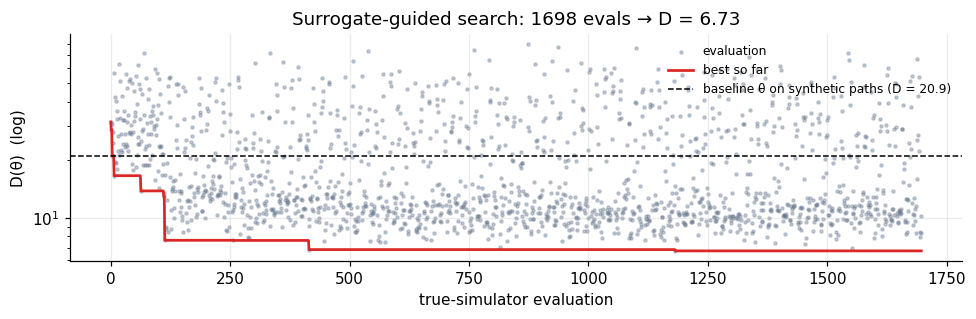

In [110]:
cal = json.load(open(OUT / "overnight_joint_logvol" / "calibration.json"))
ev = pd.DataFrame(cal["all_evals"])
ro = cal["reverse_optimum"]

fig, ax = plt.subplots(figsize=(9, 3))
ax.scatter(ev.index, ev["D"], s=4, color=SLATE, alpha=0.35, label="evaluation")
ax.plot(ev["D"].cummin().values, color=RED, lw=1.8, label="best so far")
ax.axhline(cal["measured_baseline_D"], color="black", ls="--", lw=1,
           label=f"baseline θ on synthetic paths (D = {cal['measured_baseline_D']:.1f})")
ax.set(yscale="log", xlabel="true-simulator evaluation", ylabel="D(θ)  (log)",
       title=f"Surrogate-guided search: {len(ev)} evals → D = {ro['loss_D']:.2f}")
ax.legend(frameon=False, fontsize=8); plt.tight_layout()

$D$ against each free parameter: a curved floor is identified, a flat cloud is a weak direction (a basin, not a point estimate).

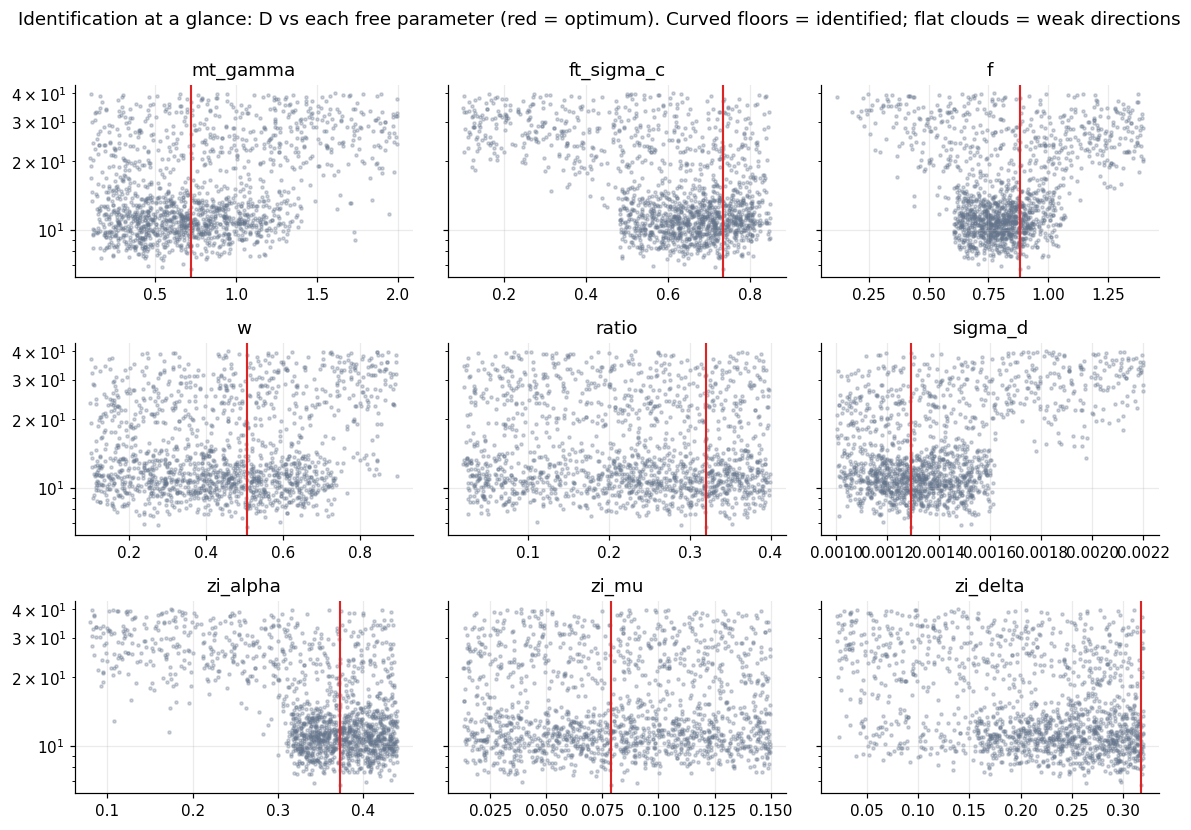

In [111]:
free = cal["free"]
fig, axes = plt.subplots(3, 3, figsize=(11, 7.5), sharey=True)
good = ev[ev["D"] < 40]
for ax, p in zip(axes.flat, free):
    ax.scatter(good[p], good["D"], s=4, color=SLATE, alpha=0.3)
    ax.axvline(ro[p], color=RED, lw=1.4)
    ax.set(title=p, yscale="log")
fig.suptitle("Identification at a glance: D vs each free parameter (red = optimum). "
             "Curved floors = identified; flat clouds = weak directions", y=1.0)
plt.tight_layout()

The loss ledger (committed runs; $D$ comparable only at fixed seed count):

In [112]:
grid_c = json.load(open(OUT / "thesis_final" / "relock" / "grid_calm.json"))["results"]["calm"]
grid_s = json.load(open(OUT / "thesis_final" / "relock" / "grid_stressed.json"))["results"]["stressed"]
fresh_s = json.load(open(OUT / "thesis_final" / "relock" / "grid_freshseed_stressed.json"))["ranked"][0]
vsum = json.load(open(OUT / "overnight_joint_logvol" / "validation_summary.json"))

pd.DataFrame([
    ("calm, locked θ (grid, full-year targets)", round(grid_c["D_grid"], 2),
     "≈26.5 on its own 20-session window — a window-selection artifact, not misfit"),
    ("stressed, locked θ (grid, 3-seed)", round(fresh_s["D_grid"], 2), "the baseline lock"),
    ("stressed, locked θ (fresh-seed re-rank)", round(fresh_s["D_fresh_mean"], 2),
     "top-ranked on common fresh seeds — lock retained"),
    ("stressed, in-sample argmin (REJECTED)", round(grid_s["D_grid"], 2),
     "beats the lock in-sample, ranks below on fresh seeds — winner's curse"),
    ("JOINT agent+FV optimum (9-d)", round(cal["reverse_optimum"]["loss_D"], 2),
     f"vs baseline {cal['measured_baseline_D']:.1f} on the same machinery; surrogate held-out R² = 0.94"),
    ("joint θ on 80 fresh synthetic paths", vsum["joint_ensembleD"],
     f"vs baseline {vsum['base_ensembleD']}; mean |gap| {vsum['joint_meanGapSD']} vs {vsum['base_meanGapSD']} SD; 9/10 in 95% CI"),
], columns=["fit", "D", "reading"]).set_index("fit")

,D,reading
fit,,
"calm, locked θ (grid, full-year targets)",43.79,≈26.5 on its own 20-session window — a window-...
"stressed, locked θ (grid, 3-seed)",6.01,the baseline lock
"stressed, locked θ (fresh-seed re-rank)",6.09,top-ranked on common fresh seeds — lock retained
"stressed, in-sample argmin (REJECTED)",5.16,"beats the lock in-sample, ranks below on fresh..."
JOINT agent+FV optimum (9-d),6.73,vs baseline 20.9 on the same machinery; surrog...
joint θ on 80 fresh synthetic paths,18.31,vs baseline 24.5; mean |gap| 0.64 vs 2.64 SD; ...


## 4. The fundamental: two-horizon (log-)volatility

$$
\log\sigma_t = m + f_t + s_t,\qquad
f_{t+1}=e^{-\alpha_f}f_t + s_f\,\varepsilon^f_t,\qquad
s_{t+1}=e^{-\alpha_s}s_t + s_s\,\varepsilon^s_t
$$
$$
\log V_{t+1}-\log V_t=\mu+\sigma_t Z_t \quad(+\ \text{bootstrapped overnight gap at each session open})
$$

A superposition-OU on log-vol (Barndorff-Nielsen & Shephard 2001), $m$ anchored so $\mathbb{E}[\sigma_t^2]=\sigma_d^2$. Two choices:

- **Log-vol, no clamp.** A single OU on $\sigma_t$ needs a positivity clamp that truncates the spikes the tails need; on log-vol a large vol-of-vol fattens tails through the clustering. This let the Merton jumps be dropped ($\delta=0$), as i.i.d. jumps add unclustered tail mass that dilutes the $\lvert r\rvert$-ACF.
- **Two horizons.** Vol autocorrelation becomes $\rho(\tau)\approx(1-w)e^{-\alpha_f\tau}+w\,e^{-\alpha_s\tau}$ — a fast intraday and a slow multi-day factor. One timescale matches only one end of the $\lvert r\rvert$-ACF; two match both, fixing the §2 long-horizon miss.

The calibrated horizons:

In [113]:
sv = ro["sv_override"]
MIN_ANN = np.sqrt(390 * 252)
hl = lambda a: np.log(2) / a
pd.DataFrame([
    ("sigma_d (level)", f"{sv['sigma_d']:.5f}/min", f"≈ {sv['sigma_d']*MIN_ANN*100:.0f}% annualised"),
    ("alpha_fast (measured)", f"{sv['alpha_fast']:.5f}", f"half-life {hl(sv['alpha_fast']):.0f} min ≈ 1 session — intraday memory"),
    ("alpha_slow (= ρ·alpha_fast)", f"{sv['alpha_slow']:.5f}",
     f"half-life {hl(sv['alpha_slow']):.0f} min ≈ {hl(sv['alpha_slow'])/390:.1f} sessions — regime memory"),
    ("variance split", f"v_fast {sv['v_fast']:.2f} / v_slow {sv['v_slow']:.2f}",
     f"slow share w = {sv['v_slow']/(sv['v_fast']+sv['v_slow']):.2f} — the horizons matter about equally"),
], columns=["parameter", "value", "interpretation"]).set_index("parameter")

,value,interpretation
parameter,,
sigma_d (level),0.00129/min,≈ 40% annualised
alpha_fast (measured),0.00178,half-life 390 min ≈ 1 session — intraday memory
alpha_slow (= ρ·alpha_fast),0.00057,half-life 1220 min ≈ 3.1 sessions — regime memory
variance split,v_fast 0.43 / v_slow 0.45,slow share w = 0.51 — the horizons matter abou...


One synthetic path — intraday variation on a multi-day swing:

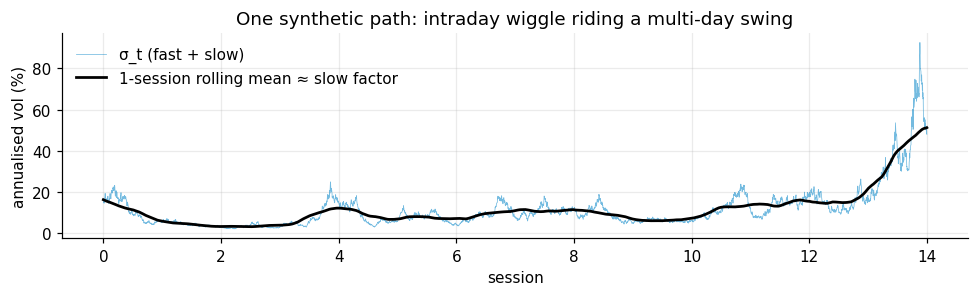

In [114]:
p1 = pd.read_csv(OUT / "overnight_joint" / "paths" / "fv_joint_s1.csv")
sig = p1["sigma_t"].to_numpy() * MIN_ANN * 100
days = 14 * 390
slow = pd.Series(sig[:days]).rolling(390, center=True, min_periods=60).mean()

fig, ax = plt.subplots(figsize=(9, 2.8))
x = np.arange(days) / 390
ax.plot(x, sig[:days], color=BLUE, lw=0.5, alpha=0.55, label="σ_t (fast + slow)")
ax.plot(x, slow, color="black", lw=1.8, label="1-session rolling mean ≈ slow factor")
ax.set(xlabel="session", ylabel="annualised vol (%)",
       title="One synthetic path: intraday wiggle riding a multi-day swing")
ax.legend(frameon=False); plt.tight_layout()

Out of sample, 80 fresh paths: the long-lag clustering the single-timescale model missed, now matched to 30 minutes:

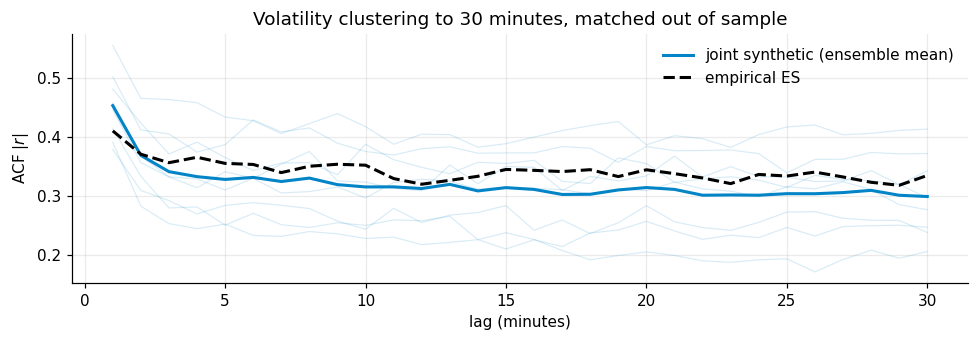

In [115]:
acf = pd.read_csv(OUT / "overnight_joint_logvol" / "synth_acf.csv")
paths = pd.read_csv(OUT / "overnight_joint_logvol" / "synth_acf_paths.csv")

fig, ax = plt.subplots(figsize=(9, 3.2))
for _, row in paths.iterrows():
    ax.plot(range(1, len(row) + 1), row.values, color=BLUE, alpha=0.15, lw=0.8)
ax.plot(acf["lag"], acf["synthetic_mean"], color=BLUE, lw=2, label="joint synthetic (ensemble mean)")
ax.plot(acf["lag"], acf["empirical"], color="black", lw=2, ls="--", label="empirical ES")
ax.set(xlabel="lag (minutes)", ylabel="ACF $|r|$", title="Volatility clustering to 30 minutes, matched out of sample")
ax.legend(frameon=False); plt.tight_layout()

In [116]:
val = pd.read_csv(OUT / "overnight_joint_logvol" / "validation.csv")
val["joint_in95"] = val["joint_in95"].map({"yes": "✓", "no": "✗ (lag-1 bid-ask bounce — thin-LOB artifact)"})
val.rename(columns={"base_gapSD": "baseline gap (SD)", "joint_gapSD": "joint gap (SD)",
                    "joint_in95": "in empirical 95% CI"})

,moment,empirical,baseline gap (SD),joint_mean,joint gap (SD),in empirical 95% CI
0,ret_std,0.0012,0.03,0.0012,0.20,✓
1,acf_r_1,-0.0045,1.39,-0.0188,2.68,✗ (lag-1 bid-ask bounce — thin-LOB artifact)
2,acf_r_5,-0.0033,0.07,-0.0030,0.04,✓
3,acf_r_10,-0.0018,0.39,-0.0010,0.17,✓
4,acf_r_20,-0.0046,0.83,-0.0020,0.47,✓
5,acf_absr_1,0.3793,2.63,0.3887,0.57,✓
6,acf_absr_5,0.3495,3.75,0.3375,0.50,✓
7,acf_absr_10,0.3339,3.86,0.3263,0.36,✓
8,acf_absr_20,0.3377,5.55,0.3150,1.30,✓
9,hill_tail_index,2.7274,7.91,2.7123,0.11,✓


## 5. What it buys: a calibrated scenario engine

The joint fit turns one replay into 80 independent stress paths through the full cleared population. The client-clearing tier those paths drive (node ∝ √capital):

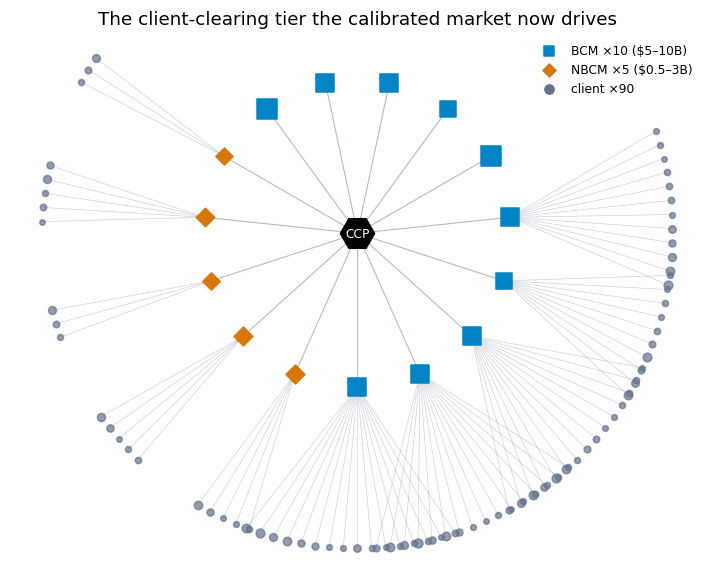

In [117]:
fig, ax = plt.subplots(figsize=(6.6, 6.6))
ang = {m.agent_id: 2 * np.pi * i / len(members) - np.pi / 2 for i, m in enumerate(members)}
for m in members:
    a = ang[m.agent_id]; x, y = np.cos(a), np.sin(a)
    ax.plot([0, x], [0, y], color=SLATE, lw=0.7, alpha=0.5, zorder=1)
    mk = "s" if isinstance(m, BankingClearingMember) else "D"
    col = BLUE if isinstance(m, BankingClearingMember) else AMBER
    ax.scatter(x, y, s=55 * np.sqrt(m.cash / 1e9), marker=mk, color=col, zorder=3)
    for j, c in enumerate(by_cm.get(m.agent_id, [])):
        aa = a + (j - len(by_cm[m.agent_id]) / 2) * 0.045
        cx, cy = 2.05 * np.cos(aa), 2.05 * np.sin(aa)
        ax.plot([x, cx], [y, cy], color=SLATE, lw=0.4, alpha=0.35, zorder=1)
        ax.scatter(cx, cy, s=20 * np.sqrt(c.cash / 1e9) + 4, color=SLATE, alpha=0.7, zorder=2)
ax.scatter(0, 0, s=500, marker="H", color="black", zorder=4)
ax.annotate("CCP", (0, 0), color="white", ha="center", va="center", fontsize=8, zorder=5)
ax.scatter([], [], marker="s", color=BLUE, label="BCM ×10 ($5–10B)")
ax.scatter([], [], marker="D", color=AMBER, label="NBCM ×5 ($0.5–3B)")
ax.scatter([], [], color=SLATE, label="client ×90")
ax.legend(frameon=False, loc="upper right", fontsize=8)
ax.set(title="The client-clearing tier the calibrated market now drives")
ax.set_aspect("equal"); ax.axis("off"); plt.tight_layout()

With scenarios that vary, one can ask which path features drive clearing severity. The answer is path volatility more than drawdown: high-vol paths ratchet the reactive IM, drain cash, and force liquidity defaults. Median path: 3 client defaults, no member defaults, fund untouched.

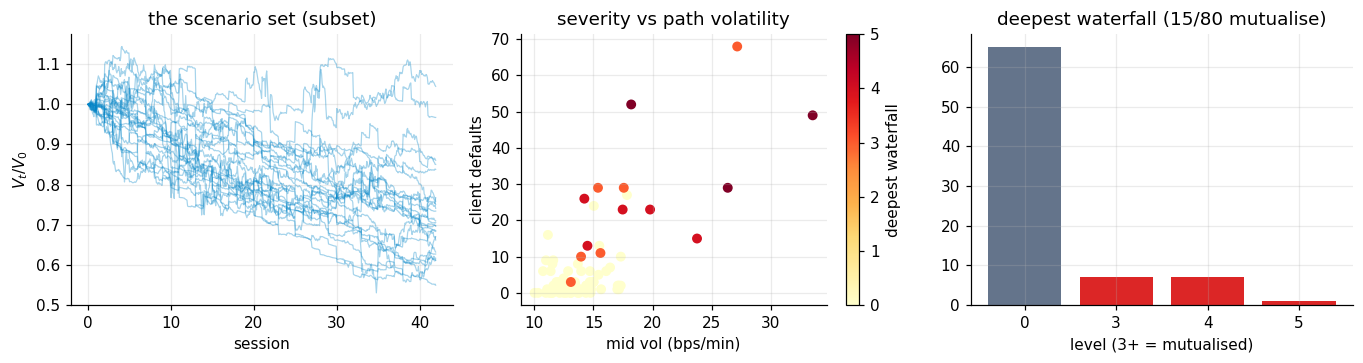

In [118]:
clr = pd.read_csv(OUT / "overnight_joint_logvol" / "clearing.csv")
summ = pd.read_csv(OUT / "synth_results" / "summary.csv")
mids = {int(f.stem.split("_s")[1]): pd.read_csv(f)["mid"].to_numpy()
        for f in (OUT / "synth_results" / "mids").glob("mid_s*.csv")}
sev = summ.copy()
sev["vol_bps"] = sev["path"].map(
    {k: np.nanstd(np.diff(np.log(v[np.isfinite(v)]))) * 1e4 for k, v in mids.items()})

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
pdir = OUT / "overnight_joint" / "paths"
for i in range(1, 25):
    f = pdir / f"fv_joint_s{i}.csv"
    if f.exists():
        v = pd.read_csv(f)["V_smooth"].to_numpy()[::30]
        axes[0].plot(np.arange(len(v)) * 30 / 390, v / v[0], color=BLUE, alpha=0.35, lw=0.8)
axes[0].set(title="the scenario set (subset)", xlabel="session", ylabel="$V_t/V_0$")
o = sev.sort_values("deepest_wf").index
sc = axes[1].scatter(sev.loc[o, "vol_bps"], sev.loc[o, "client_def"],
                     c=sev.loc[o, "deepest_wf"], cmap="YlOrRd", vmin=0, vmax=5, s=30)
axes[1].set(title="severity vs path volatility", xlabel="mid vol (bps/min)", ylabel="client defaults")
plt.colorbar(sc, ax=axes[1], label="deepest waterfall")
wf = clr["deepest_wf"].value_counts().sort_index()
axes[2].bar(wf.index.astype(str), wf.values, color=[SLATE if int(k) < 3 else RED for k in wf.index])
axes[2].set(title=f"deepest waterfall ({int((clr['deepest_wf']>=3).sum())}/{len(clr)} mutualise)",
            xlabel="level (3+ = mutualised)")
plt.tight_layout()

One experiment the engine supports (150 seeds/arm, COVID window, fixed fund): margin levels relocate risk rather than remove it — a freeze trap where early capital-floor breaches freeze clearing and trapped clients default bigger, onto the member.

In [119]:
rows = pd.read_csv(OUT / "thesis_final" / "experiments" / "rows.csv")
st, ca = rows[rows.regime == "stressed"], rows[rows.regime == "calm"]
lab = {"flat04": "Flat 4%", "flat08": "Flat 8%", "flat12": "Flat 12%", "reactive": "Reactive (4→11.4%)"}
pd.DataFrame({
    "cost calm ($B)": (ca.groupby("margin")["im_mean"].mean() / 1e9).round(1),
    "cost stress peak ($B)": (st.groupby("margin")["im_peak"].mean() / 1e9).round(1),
    "client defaults": st.groupby("margin")["client_defaults"].mean().round(1),
    "member defaults": st.groupby("margin")["cm_defaults"].mean().round(2),
    "reach fund (%)": (100 * st.groupby("margin")["mutualised_l3"].mean()).round(0),
}).loc[["flat04", "flat08", "flat12", "reactive"]].rename(index=lab)

,cost calm ($B),cost stress peak ($B),client defaults,member defaults,reach fund (%)
margin,,,,,
Flat 4%,18.1,18.6,14.8,0.01,1.0
Flat 8%,31.7,33.8,11.1,0.35,30.0
Flat 12%,42.3,46.3,6.9,0.55,42.0
Reactive (4→11.4%),18.1,38.5,10.1,0.33,25.0


## 6. Where this goes

- **Joint calibration with the clearing layer active** — the stressed fit is not clearing-invariant (freezes and deleveraging feed back into prices); the surrogate loop extends to market+clearing jointly at ~the same budget.
- **Richer volatility structure** — the superposition-OU admits $n$ factors; whether a third horizon is identified is what the $D$-vs-parameter slices answer.
- **Endogenous fundamental** — today $V_t$ is exogenous, so impact enters only via transaction costs; letting order-flow imbalance move $V_t$ opens the margin-spiral channel.
- **Other assets and regimes** — inputs are just BBO + OHLCV; clearing constants are a config, not a calibration.

*Interactive companion:* `api/server.py` serves this simulator live (~0.3 s/session).